## Desarrollo tarea HW Sesión 1

Felipe López Vergara

- Una función que permita descargar datos donde los inputs son tickers que es una lista de tickers, start fecha de comienzo y end fecha de término. Esta función, debe retornar un dataframe con los precios de cierre de los tickers.

def descargar_datos_yf(tickers, start, end):
    # Ingreseo codigos aca

In [23]:
# Importación de Librerías
import yfinance as yf
import pandas as pd
import numpy as np
from scipy import stats

In [24]:
# Extracción de datos utilizando yfinance
def descargar_datos_yf(tickers, start, end):
    data = yf.download(tickers, start=periodo[0], end=periodo[1], progress=False)
    return data

tickers = ['AAPL', 'JPM', 'TSLA']
periodo = ('2021-01-01', '2024-01-01')

df = descargar_datos_yf(tickers, periodo[0], periodo[1])['Close']
df.head()

Ticker,AAPL,JPM,TSLA
2021-01-04,125.740837,109.491562,243.256668
2021-01-05,127.295502,110.087357,245.036667
2021-01-06,123.010506,115.256584,251.993332
2021-01-07,127.208015,119.041534,272.013336
2021-01-08,128.305984,119.172951,293.339996


* Una función que permita calcular retornos del dataframe. Para ello utilice la función incorporada del dataframe df.pct_changes().dropna(). La función debe retornar los retornos del dataframe df

def calcula_retornos(df):
    # ingrese codigos aca

In [25]:
# Cálculos de retornos del DataFrame
def calcula_retornos(df):
    retornos = df.pct_change().dropna()
    return retornos

df_retornos = calcula_retornos(df)
df_retornos.head()

Ticker,AAPL,JPM,TSLA
2021-01-05,0.012364,0.005441,0.007317
2021-01-06,-0.033662,0.046956,0.028390
2021-01-07,0.034123,0.032839,0.079447
2021-01-08,0.008631,0.001104,0.078403
2021-01-11,-0.023249,0.014924,-0.078214


- Una función que calcule estadísticos de tendencia central, dispersión, localización y forma.

def resumen_estadistico_retornos(df):
    # ingrese codigos aca

Las medidas que debe incoporar esta función, son la media, volatilidad, asimetría, kurtosis, máximo y mínimo de los retornos.

In [26]:
def resumen_estadistico_retornos(df):
        arr = df.to_numpy()
        media = np.mean(arr, axis=0)
        rango = np.max(arr, axis=0) - np.min(arr, axis=0)
        varianza = np.var(arr, axis=0, ddof=1)
        desviacion = np.std(arr, axis=0, ddof=1)
        coef_dev = desviacion / media
        skewness = stats.skew(arr, axis=0)
        kurtosis = stats.kurtosis(arr, axis=0)
        maximo = np.max(arr, axis=0)
        minimo = np.min(arr, axis=0)
        resumen = pd.DataFrame({
            'Media': media,
            'Rango': rango,
            'Varianza': varianza,
            'Desviación Estándar': desviacion,
            'Coeficiente de Variación': coef_dev,
            'Skewness': skewness,
            'Kurtosis': kurtosis,
            'Máximo': maximo,
            'Mínimo': minimo
        }, index=df.columns)
        return resumen

resumen_estadistico_retornos(df_retornos)

,Media,Rango,Varianza,Desviación Estándar,Coeficiente de Variación,Skewness,Kurtosis,Máximo,Mínimo
Ticker,,,,,,,,,
AAPL,0.000705,0.147654,0.000307,0.017511,24.850853,0.099000,1.715110,0.088975,-0.058679
JPM,0.000631,0.136973,0.000235,0.015343,24.302717,0.133709,1.833461,0.075510,-0.061463
TSLA,0.000715,0.318835,0.001376,0.037099,51.890389,0.118360,1.732884,0.196412,-0.122422


- Una función que permite visualizar retornos. Para ello, la función debe crear un subplot que contenga los graficos de series de tiempo, histograma y boxplot (cada figura en un subplot).

def plot_retornos(df):
    # ingrese codigos aca

In [27]:
# Importación de librerías para visualización
from matplotlib import pyplot as plt
import seaborn as sns

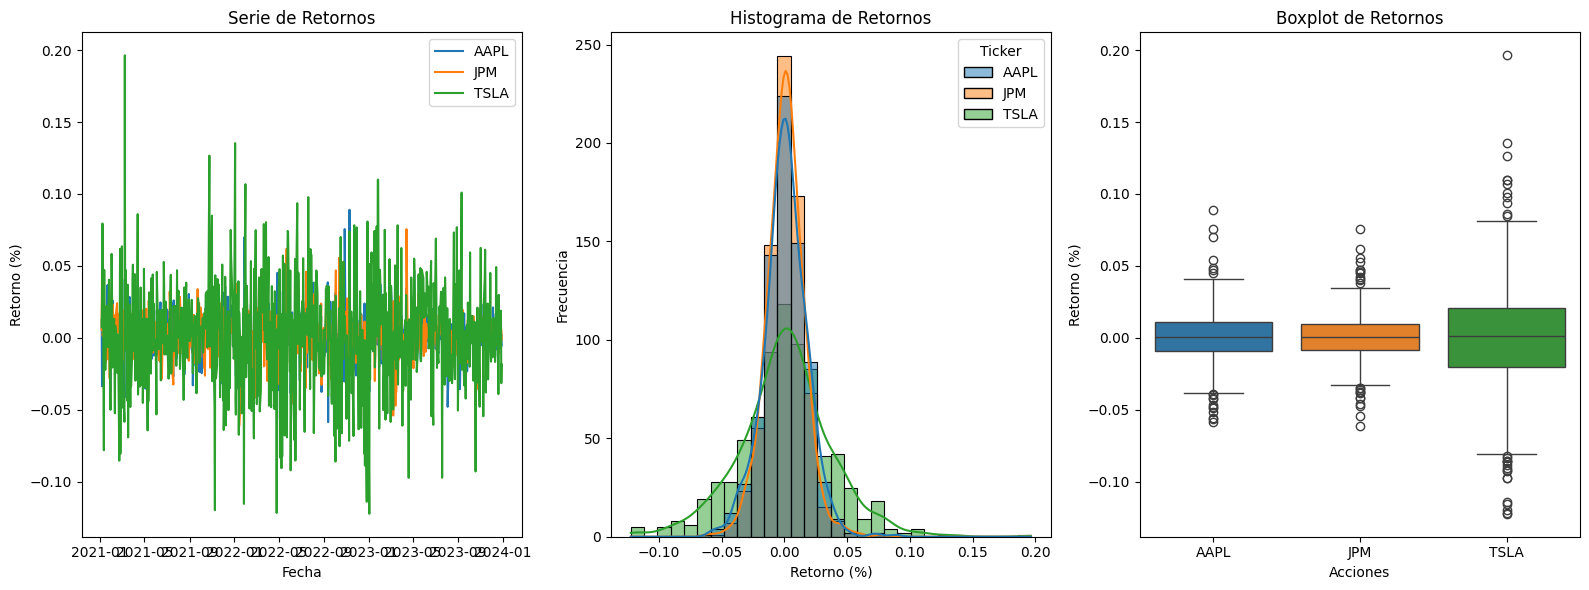

In [28]:
def plot_retornos(df):
    fig, axes = plt.subplots(1,3, figsize=(16, 6))
    
    #Primer gráfico: Serie de Tiempo
    axes[0].plot(df)
    axes[0].set_title("Serie de Retornos")
    axes[0].set_xlabel("Fecha")
    axes[0].set_ylabel("Retorno (%)")
    axes[0].legend(df.columns)

    #Segundo gráfico: Histograma
    sns.histplot(df, bins=30, kde=True, ax=axes[1])
    axes[1].set_title("Histograma de Retornos")
    axes[1].set_xlabel("Retorno (%)")
    axes[1].set_ylabel("Frecuencia")

    #Tercer gráfico: Boxplot
    sns.boxplot(df, orient='v', ax=axes[2])
    axes[2].set_title("Boxplot de Retornos")
    axes[2].set_xlabel("Acciones")
    axes[2].set_ylabel("Retorno (%)")
    
    return fig, axes

plot_retornos(df_retornos)

plt.tight_layout()
plt.show()


- De acuerdo a lo anterior, responda lo siguiente :

1) ¿ Cuál es el activo con mayor riesgo según volatilidad?

El activo con mayor riesgo según su volatilidad es Tesla (TSLA) ya que cuenta con mayor desviación en sus retornos.

2) ¿ Algún activo presenta distribución de retornos no simétrica o con colas pesadas?

Los 3 activos Apple (AAPL), JP Morgan (JPM) y Tesla (TSLA) tienen una distribución más bien simétrica al tener un índice Skewness cercano a cero y menor que 0,5, también se puede decir que tienen una asimetría leve.

Por otra parte los 3 activos Apple (AAPL), JP Morgan (JPM) y Tesla (TSLA) si cuantan con una distribución de retornos con colas pesadas tipo Leptocúrtica al tener un valor de exceso de Kurtosis mayor a 0.

3) ¿ Qué diferencias observas entre TSLA y JPM respecto a riesgo?

Observo que la acción de Tesla TSLA cuanta con una mayor grado de volatilidad en sus retornos respecto a la acción Jp morgan JPM y se puede asosiar a un mayor riesgo mostrando que el precio de la acción puede subir o bajar mucho de un día a otro. También TSLA muestra mayores cantidades de valores outliers, en cambio JPM muestra retornos más estables.



